# Pricing the run before launch, part 2: cost model and calibrated walltime

Part 1 ended with a spec: predict `log(wall_minutes)` from pre-launch features only,
split by campaign, keep censored labels out of the point model, and stress-test the
apportioned block. This notebook executes it. Three deliverables:

1. an honest estimate of how well run cost can be predicted before launch,
2. an account of what actually drives cost,
3. walltime requests with a coverage guarantee, compared against my real requests.

Plus a preview of the seed-ordering policy. Part 3 (planned) replays both policies
against the actual launch history.

In [1]:
%matplotlib inline
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt, pathlib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict, train_test_split
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

ROOT = pathlib.Path().resolve()
while not (ROOT / "data").exists():
    ROOT = ROOT.parent
con = duckdb.connect()
for t in ("runs", "requests"):
    con.execute(f"CREATE OR REPLACE VIEW {t} AS SELECT * FROM read_parquet('{ROOT/'data'/(t+'.parquet')}')")
runs = con.execute("SELECT * FROM runs").df()

def error_factor(residuals):
    """exp(median |log error|): 1.0 is perfect, 2.0 means typically 2x off either way.
    Easier to reason about for scheduling than a squared-error score."""
    return float(np.exp(np.median(np.abs(residuals))))

## 1. The training table

Two kinds of row would corrupt a cost model and are excluded from the labels: stubs
(seconds-long restricted evaluations with no iteration record, a different population)
and censored runs (budget-truncated, so their recorded cost is a lower bound). Both
filters are computed from post-run columns, which is fine for selecting training rows
but means neither flag can ever be a feature.

In [2]:
runs["is_stub"]     = (runs.status == "unknown") & runs.n_iter.isna()
runs["is_censored"] = (runs.status == "max_iter") | (runs.n_iter >= runs.max_iter)

tr = runs[(runs.wall_minutes > 0) & ~runs.is_stub & ~runs.is_censored.fillna(False)].copy()
tr = tr.reset_index(drop=True)

CAT = ["source", "seed_family", "mixing", "machine"]   # categoricals, known at launch
NUM = ["grid_k", "basis_nharm", "tol", "max_iter"]      # numerics, known at launch
FEATURES = CAT + NUM

X = tr[FEATURES].copy()
for c in CAT:
    X[c] = X[c].astype("category")
y = np.log(tr["wall_minutes"].values)
groups = tr["campaign"].values          # split key, deliberately not a feature

print(f"{len(tr)} trainable rows across {tr.campaign.nunique()} campaigns")
print(tr.groupby("source").size().rename("rows").to_string())

1156 trainable rows across 31 campaigns
source
continuum_scf     910
lattice_scf       106
lattice_scf_v2    140


## 2. The split decides whether the numbers mean anything

Runs within a campaign share physics, grid settings and launch configuration. A random
split scatters each campaign across train and test, so the model gets scored on near
copies of rows it trained on. Splitting by whole campaigns instead asks the question I
actually care about: what does this model do on an experiment it has never seen?

In [3]:
hgb = HistGradientBoostingRegressor(categorical_features="from_dtype",
                                    random_state=0, max_iter=300, learning_rate=0.05)

pred_random = cross_val_predict(hgb, X, y, cv=KFold(5, shuffle=True, random_state=0))
pred_group  = cross_val_predict(hgb, X, y, cv=GroupKFold(5), groups=groups)

for name, p in [("random 5-fold", pred_random), ("leave-campaign-out", pred_group)]:
    print(f"{name:20s} typically {error_factor(y-p):.2f}x off | R2(log) = {r2_score(y, p):.2f}")

random 5-fold        typically 1.58x off | R2(log) = 0.82
leave-campaign-out   typically 2.76x off | R2(log) = 0.21


Same model, same data: R2 = 0.82 under a random split, 0.21 under leave-campaign-out.
The first number is leakage, not skill, and it is the number most tempting to report.
Everything below is leave-campaign-out unless stated otherwise.

## 3. A baseline, then trees

In [4]:
ridge = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUM)])),
    ("model", Ridge(alpha=1.0)),
])
pred_ridge = cross_val_predict(ridge, tr[FEATURES], y, cv=GroupKFold(5), groups=groups)

pd.DataFrame({
    "typical_factor_off": [round(error_factor(y-pred_ridge), 2), round(error_factor(y-pred_group), 2)],
    "R2_log":             [round(r2_score(y, pred_ridge), 2),    round(r2_score(y, pred_group), 2)],
}, index=["ridge baseline", "gradient-boosted trees"])

,typical_factor_off,R2_log
ridge baseline,4.41,0.22
gradient-boosted trees,2.76,0.21


In [5]:
tr["abs_logerr"] = np.abs(y - pred_group)
(tr.groupby("source")["abs_logerr"]
   .apply(lambda r: round(float(np.exp(r.median())), 2))
   .rename("typical_factor_off").to_frame())

,typical_factor_off
source,
continuum_scf,2.48
lattice_scf,6.26
lattice_scf_v2,2.80


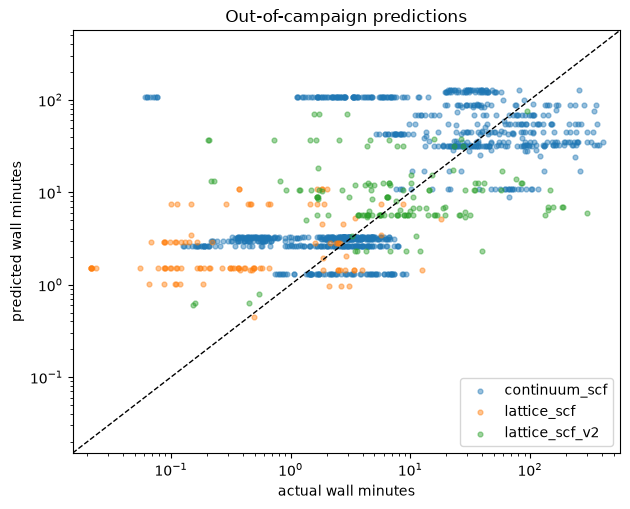

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
colors = {"continuum_scf": "tab:blue", "lattice_scf": "tab:orange", "lattice_scf_v2": "tab:green"}
for src, gdf in tr.assign(pred=np.exp(pred_group)).groupby("source"):
    ax.scatter(gdf.wall_minutes, gdf.pred, s=12, alpha=.45, color=colors[src], label=src)
lims = [tr.wall_minutes.min()*0.7, tr.wall_minutes.max()*1.4]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims,
       xlabel="actual wall minutes", ylabel="predicted wall minutes",
       title="Out-of-campaign predictions")
ax.legend()
plt.tight_layout()

The trees cut the ridge baseline's 4.4x to 2.8x. Per source, the picture is uneven in an
informative way: about 2.5x on continuum, where most rows and nearly all the compute
live, and 6x on the tiny `lattice_scf` source, which has only two campaigns, so
leave-campaign-out leaves it essentially untrained. I would not ship anything for that
source, and I say so rather than averaging it away.

## 4. How stable is 2.8x?

The pooled median can hide a lot, so look at it fold by fold, then stress the largest
campaign (which is also where part 1's apportioned wall-times concentrate):

In [7]:
for k, (tri, tei) in enumerate(GroupKFold(5).split(X, y, groups)):
    m = HistGradientBoostingRegressor(categorical_features="from_dtype",
                                      random_state=0, max_iter=300, learning_rate=0.05
                                      ).fit(X.iloc[tri], y[tri])
    fac = error_factor(y[tei] - m.predict(X.iloc[tei]))
    top = tr.iloc[tei].campaign.value_counts().idxmax()
    print(f"fold {k}: {fac:6.2f}x  ({len(tei)} rows, {len(set(groups[tei]))} campaigns, largest {top})")

fold 0:   1.39x  (305 rows, 1 campaigns, largest campaign_12)


fold 1:   2.77x  (213 rows, 6 campaigns, largest campaign_01)


fold 2:   5.39x  (213 rows, 8 campaigns, largest campaign_13)


fold 3:   2.26x  (213 rows, 10 campaigns, largest campaign_02)


fold 4:  17.84x  (212 rows, 6 campaigns, largest campaign_33)


In [8]:
biggest = tr.campaign.value_counts().idxmax()
keep = (tr.campaign != biggest).values
pred_wo = cross_val_predict(hgb, X[keep], y[keep], cv=GroupKFold(5), groups=groups[keep])
print(f"dropping {biggest} ({(~keep).sum()} rows): "
      f"{error_factor(y-pred_group):.2f}x -> {error_factor(y[keep]-pred_wo):.2f}x")

dropping campaign_12 (305 rows): 2.76x -> 4.35x


Fold by fold the error runs from 1.4x to 18x. The easiest fold is the largest campaign
tested alone: a big homogeneous block that the rest of the data predicts well. The worst
fold is dominated by the tiny two-campaign `lattice_scf` source (untrained
out-of-campaign, as section 3 showed) plus a handful of one-off campaigns, and there
the model is close to useless.
Dropping the largest campaign moves the pooled number from 2.8x to 4.4x, which given the
fold table is mostly composition (the easiest quarter of the test rows left the pool),
not evidence that the block was propping up training.

So the honest summary is a range with a mechanism, not a single number: big homogeneous
campaigns predict to about 1.4x, genuinely new small campaigns can be 5 to 20x, and the
pooled 2.8x sits where it does because most rows belong to the first kind.

## 5. What the model leans on

Permutation importance, measured on held-out campaigns. Measured on a random holdout
instead, any feature that helps identify an already-seen campaign gets inflated credit,
which is the same leakage as in section 2.

,importance
max_iter,0.231
tol,0.217
grid_k,0.200
seed_family,0.004
mixing,0.004
machine,0.002
source,0.001
basis_nharm,-0.012


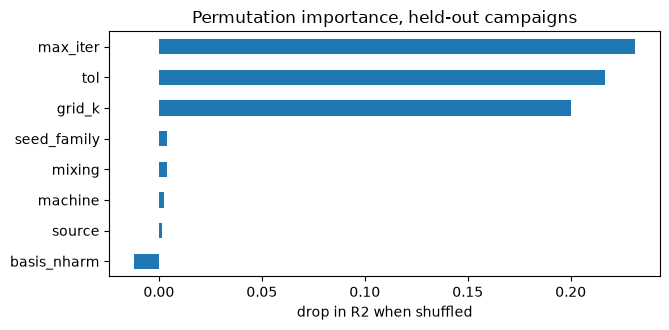

In [9]:
camps = np.array(sorted(tr.campaign.unique()))
rng = np.random.RandomState(0); rng.shuffle(camps)
held = np.isin(groups, camps[:10])
fit = HistGradientBoostingRegressor(categorical_features="from_dtype",
                                    random_state=0, max_iter=300, learning_rate=0.05
                                    ).fit(X[~held], y[~held])
pi = permutation_importance(fit, X[held], y[held], n_repeats=10, random_state=0)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(6.8, 3.4))
imp.plot.barh(ax=ax)
ax.set(xlabel="drop in R2 when shuffled", title="Permutation importance, held-out campaigns")
plt.tight_layout()
imp.sort_values(ascending=False).round(3).rename("importance").to_frame()

Three operator-set numerics carry roughly equal weight (`max_iter`, `tol`, `grid_k`),
everything else is near zero. Two readings.

First, `max_iter` and `tol` are choices, not physics. Operators hand big iteration
budgets and tight tolerances to runs they expect to be hard, so the model is partly
borrowing the operator's own judgment. Legitimate for prediction, since both are known
before launch, but not causation. The physical driver is `grid_k`, consistent with the
grid_k^6.4 power law measured in part 1.

Second, `seed_family` scores about zero here even though part 1 showed strong seed
effects within a campaign. Both are true: seed vocabularies are campaign-bound, so seed
knowledge does not transfer to unseen campaigns. That matters for the seed policy below,
its evidence base is within-campaign comparisons, not this model.

## 6. Walltime requests with a guarantee

A point prediction is not a reservation: undershoot and the scheduler kills the job.
What I want is the smallest request that is safe at a chosen level. Split conformal
prediction gives exactly that without distributional assumptions: hold out a calibration
set, take the 95th percentile of the (actual minus predicted) log residuals, and pad
every future prediction by it.

The calibration regime matters, so I evaluate two. Steady state first: future runs
resemble the population I have history for, so calibration is a random holdout.

In [10]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.40, random_state=0)
X_cal, X_te, y_cal, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=0)

cmodel = HistGradientBoostingRegressor(categorical_features="from_dtype",
                                       random_state=0, max_iter=300, learning_rate=0.05
                                       ).fit(X_tr, y_tr)
cal_resid = y_cal - cmodel.predict(X_cal)
for target in (0.90, 0.95):
    q = np.quantile(cal_resid, target)
    covered = np.mean(y_te <= cmodel.predict(X_te) + q)
    print(f"{target:.0%} nominal -> {covered:5.1%} empirical | request = prediction x {np.exp(q):.1f}")

90% nominal -> 91.4% empirical | request = prediction x 3.3
95% nominal -> 96.6% empirical | request = prediction x 4.6


Coverage lands on target, and the price of a 95% guarantee is about 4.6x the point
prediction (3.3x at 90%). Concretely: a run predicted at 30 minutes gets a 95%-safe
request of roughly 140 minutes.

The stress case is a genuinely new campaign, calibrating and testing on disjoint
campaign groups:

In [11]:
g = np.array(sorted(tr.campaign.unique()))
g_tr, g_cal, g_te = g[:int(.6*len(g))], g[int(.6*len(g)):int(.8*len(g))], g[int(.8*len(g)):]
m_tr, m_cal, m_te = [np.isin(groups, s) for s in (g_tr, g_cal, g_te)]
cold = HistGradientBoostingRegressor(categorical_features="from_dtype",
                                     random_state=0, max_iter=300, learning_rate=0.05
                                     ).fit(X[m_tr], y[m_tr])
qc = np.quantile(y[m_cal] - cold.predict(X[m_cal]), 0.95)
print(f"cold start, 95% nominal -> {np.mean(y[m_te] <= cold.predict(X[m_te]) + qc):.0%} empirical "
      f"| request = prediction x {np.exp(qc):.0f}")

cold start, 95% nominal -> 100% empirical | request = prediction x 112


For an unseen campaign the same guarantee costs about 100x headroom. That is not a bug
in the method, it is the honest price of extrapolation given section 4. So the policy is
scoped: calibrated per-run requests for run types with history, a conservative default
for cold starts.

Against current practice:

In [12]:
con.execute("""
SELECT round(median(requested_walltime_min))                       AS median_request_min,
       (SELECT round(median(wall_minutes),1) FROM runs
         WHERE machine='perlmutter' AND wall_minutes>0)            AS median_realized_min
FROM requests WHERE machine='perlmutter'
""").df().assign(blanket_headroom=lambda d: (d.median_request_min/d.median_realized_min).round(0))

,median_request_min,median_realized_min,blanket_headroom
0,720.0,42.8,17.0


My actual perlmutter requests carried a median 17x cushion over median realized cost,
applied as a flat habit. Per-run sizing at 4.6x with an explicit 95% guarantee is the
upgrade: short jobs stop hoarding 12-hour reservations, and the safety level becomes a
dial instead of a hope.

## 7. Seed ordering, previewed

In [13]:
(tr[tr.source == "continuum_scf"]
   .groupby("seed_family")["wall_minutes"].agg(count="size", median_min="median")
   .query("count >= 15").sort_values("median_min").round(2))

,count,median_min
seed_family,,
overhauser_warmstart,115,2.31
skx_strong,117,2.50
skx,172,3.58
cycloid,165,3.89
fm,59,20.98
stripe,36,25.25
wigner,33,35.50
skx_str,65,50.31
ohaus,53,75.92


Within the continuum source, median cost per seed family spans about 30x (2.3 to 76
minutes). Ordering a sweep cheap-first, and stopping early when any converged answer
suffices, is close to free savings.

Two constraints before calling it a policy. Seeds are not interchangeable, different
seeds deliberately probe different candidate states, so early stopping only applies when
any converged answer will do; otherwise this is about ordering and budgeting a sweep,
not skipping arms. And per section 5 the evidence is within-campaign, so the ranking
holds for the campaign types it came from, not universally.

## 8. Honest summary

Usable now:
- pre-launch cost prediction at about 2.5x typical error for the dominant source
  (leave-campaign-out, R2 0.21 pooled, fold range 1.4x to 18x, reported as such),
- calibrated 95% walltime requests at 4.6x headroom in the steady-state regime,
  against a 17x status quo,
- cheap-first ordering of seed sweeps within known campaign types (about 30x spread).

Not usable, and said out loud:
- tight requests for cold-start campaigns (honest headroom there is about 100x),
- anything for the two-campaign `lattice_scf` source,
- seed rankings transplanted across campaigns.

Next: part 3 replays both policies against the recorded launch history to attach
wall-hours to them, the exporter gains an `is_apportioned` flag, and if the censored
tail starts driving quantiles the model graduates to a survival treatment.